# 신용카드사기탐지_모델만들기

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [3]:
data = pd.read_csv("./data/fraud.csv")
data.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 22 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   trans_date_trans_time  object 
 1   cc_num                 int64  
 2   merchant               object 
 3   category               object 
 4   amt                    float64
 5   first                  object 
 6   last                   object 
 7   gender                 object 
 8   street                 object 
 9   city                   object 
 10  state                  object 
 11  zip                    int64  
 12  lat                    float64
 13  long                   float64
 14  city_pop               int64  
 15  job                    object 
 16  dob                    object 
 17  trans_num              object 
 18  unix_time              int64  
 19  merch_lat              float64
 20  merch_long             float64
 21  is_fraud               int64  
dtypes: float64(5), int

In [5]:
data.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06,1.852394e+06
mean,4.173860e+17,7.006357e+01,4.881326e+04,3.853931e+01,-9.022783e+01,8.864367e+04,1.358674e+09,3.853898e+01,-9.022794e+01,5.210015e-03
std,1.309115e+18,1.592540e+02,2.688185e+04,5.071470e+00,1.374789e+01,3.014876e+05,1.819508e+07,5.105604e+00,1.375969e+01,7.199217e-02
min,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902742e+01,-1.666716e+02,0.000000e+00
25%,1.800429e+14,9.640000e+00,2.623700e+04,3.466890e+01,-9.679800e+01,7.410000e+02,1.343017e+09,3.474012e+01,-9.689944e+01,0.000000e+00
50%,3.521417e+15,4.745000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.443000e+03,1.357089e+09,3.936890e+01,-8.744069e+01,0.000000e+00
75%,4.642255e+15,8.310000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.374581e+09,4.195626e+01,-8.024511e+01,0.000000e+00
max,4.992346e+18,2.894890e+04,9.992100e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.388534e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [10]:
data.isna().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [6]:
obj_cols = data.select_dtypes(include="object")
num_cols = data.select_dtypes(exclude="object")

In [14]:
for col in obj_cols:
    print("="*30, col, "="*30)
    print("nunique: ", obj_cols[col].nunique())
    print(obj_cols[col].value_counts())
    
#     print(data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False))
    result = data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False)
    result = result[result['is_fraud'] > 0]
    print(result)

============================== trans_date_trans_time ==============================
nunique:  1819551
trans_date_trans_time
2019-04-22 16:02:01    4
2020-06-01 01:37:47    4
2020-06-02 12:47:07    4
2020-10-05 19:37:49    4
2020-12-13 17:53:47    4
                      ..
2019-01-01 00:20:15    1
2019-01-01 00:21:32    1
2019-01-01 00:22:06    1
2019-01-01 00:22:18    1
2019-01-01 00:00:44    1
Name: count, Length: 1819551, dtype: int64
                       is_fraud
trans_date_trans_time          
2019-09-11 22:58:11    1.000000
2019-12-22 01:09:30    1.000000
2019-02-12 23:49:17    1.000000
2019-09-23 06:33:47    1.000000
2019-05-03 04:38:52    1.000000
...                         ...
2020-07-21 23:49:05    0.333333
2020-09-27 15:13:13    0.333333
2020-10-12 22:31:39    0.333333
2019-08-03 22:42:34    0.333333
2020-06-15 22:03:50    0.333333

[9646 rows x 1 columns]
============================== merchant ==============================
nunique:  693
merchant
fraud_Kilback LLC      

                                is_fraud
job                                     
Air traffic controller          1.000000
Careers adviser                 1.000000
Broadcast journalist            1.000000
Armed forces technical officer  1.000000
Contracting civil engineer      1.000000
...                                  ...
Designer, furniture             0.001144
Designer, exhibition/display    0.000914
Statistician                    0.000823
Health physicist                0.000686
Contractor                      0.000458

[494 rows x 1 columns]
============================== dob ==============================
nunique:  984
dob
1977-03-23    8044
1988-09-15    6574
1981-08-29    6571
1955-05-06    5121
1960-01-13    4395
              ... 
1936-05-04       7
1964-09-17       7
1963-02-26       7
1999-10-26       7
1998-08-02       6
Name: count, Length: 984, dtype: int64
            is_fraud
dob                 
1927-02-03  1.000000
1932-08-10  1.000000
1932-05-09  1.000000
1931-0

============================== cc_num ==============================
count    1.852394e+06
mean     4.173860e+17
std      1.309115e+18
min      6.041621e+10
25%      1.800429e+14
50%      3.521417e+15
75%      4.642255e+15
max      4.992346e+18
Name: cc_num, dtype: float64
cc_num
30270432095985      4392
6538441737335434    4392
4642255475285942    4386
6538891242532018    4386
4364010865167176    4386
                    ... 
501894933032           7
4975457191020          7
6577777028615915       7
180097223252063        7
4295296907373          6
Name: count, Length: 999, dtype: int64


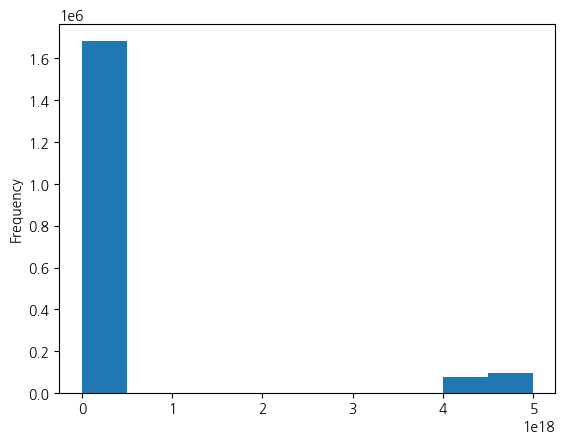

                     is_fraud
cc_num                       
4659625317833446364  1.000000
4714017207228610634  1.000000
6517779374888867     1.000000
5301645381939419     1.000000
503886119844         1.000000
...                       ...
4809701904914        0.000685
3518234918950662     0.000549
3576431665303017     0.000458
6011109736646996     0.000458
6011893664860915     0.000457

[976 rows x 1 columns]
============================== amt ==============================
count    1.852394e+06
mean     7.006357e+01
std      1.592540e+02
min      1.000000e+00
25%      9.640000e+00
50%      4.745000e+01
75%      8.310000e+01
max      2.894890e+04
Name: amt, dtype: float64
amt
1.14       779
1.10       745
1.04       744
1.08       741
1.25       737
          ... 
537.02       1
1309.21      1
850.87       1
516.74       1
540.49       1
Name: count, Length: 60616, dtype: int64


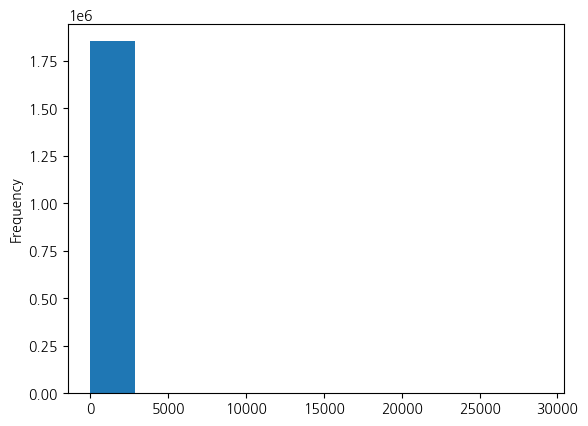

        is_fraud
amt             
281.28  1.000000
984.69  1.000000
984.59  1.000000
684.27  1.000000
277.20  1.000000
...          ...
2.25    0.001629
1.51    0.001580
1.78    0.001558
1.91    0.001558
1.06    0.001490

[8296 rows x 1 columns]
============================== zip ==============================
count    1.852394e+06
mean     4.881326e+04
std      2.688185e+04
min      1.257000e+03
25%      2.623700e+04
50%      4.817400e+04
75%      7.204200e+04
max      9.992100e+04
Name: zip, dtype: float64
zip
82514    5116
73754    5116
48088    5115
34112    5108
61454    4392
         ... 
61364       7
46510       7
37411       7
16041       7
52658       6
Name: count, Length: 985, dtype: int64


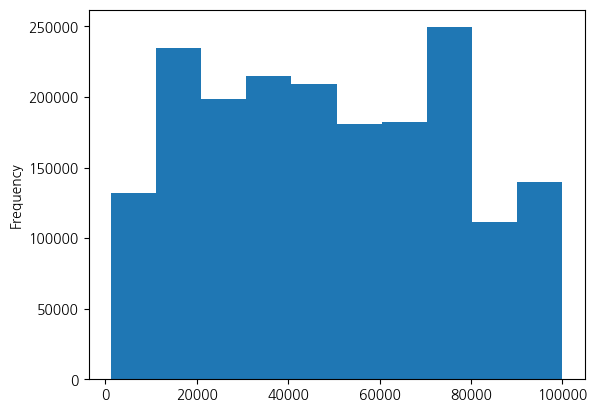

       is_fraud
zip            
99921  1.000000
66958  1.000000
62896  1.000000
65745  1.000000
68375  1.000000
...         ...
36869  0.000685
75092  0.000549
85020  0.000458
28405  0.000458
80120  0.000457

[963 rows x 1 columns]
============================== lat ==============================
count    1.852394e+06
mean     3.853931e+01
std      5.071470e+00
min      2.002710e+01
25%      3.466890e+01
50%      3.935430e+01
75%      4.194040e+01
max      6.669330e+01
Name: lat, dtype: float64
lat
43.0048    5116
36.3850    5116
42.5164    5115
26.1184    5108
41.3851    4392
           ... 
40.7547       7
36.8294       7
34.0066       7
41.1225       7
40.7067       6
Name: count, Length: 983, dtype: int64


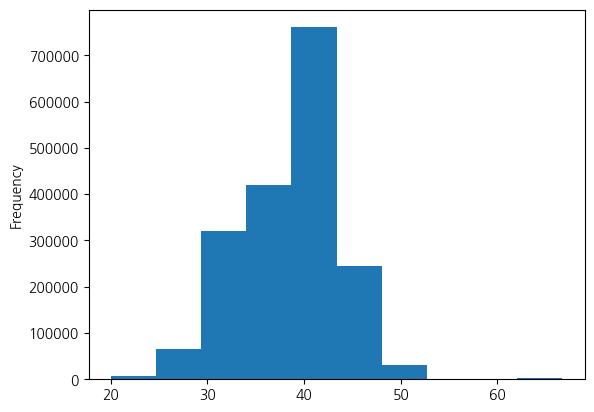

         is_fraud
lat              
47.6633  1.000000
66.6933  1.000000
27.8942  1.000000
47.5412  1.000000
36.7410  1.000000
...           ...
32.4204  0.000685
33.6372  0.000549
33.5623  0.000458
34.2651  0.000458
39.5994  0.000457

[961 rows x 1 columns]
============================== long ==============================
count    1.852394e+06
mean    -9.022783e+01
std      1.374789e+01
min     -1.656723e+02
25%     -9.679800e+01
50%     -8.747690e+01
75%     -8.015800e+01
max     -6.795030e+01
Name: long, dtype: float64
long
-108.8964    5116
-98.0727     5116
-82.9832     5115
-81.7361     5108
-91.0391     4392
             ... 
-95.4460        7
-73.9925        7
-85.2356        7
-76.2701        7
-91.2268        6
Name: count, Length: 983, dtype: int64


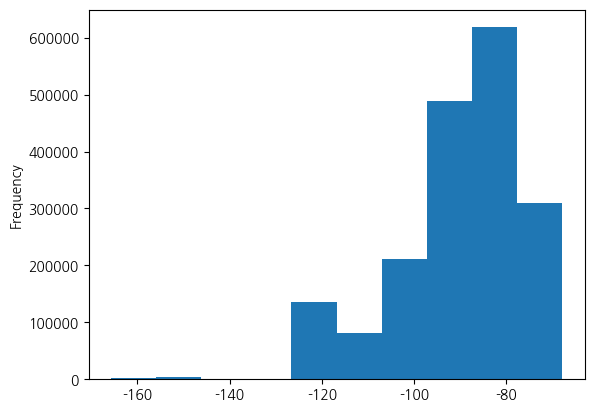

           is_fraud
long               
-133.1171  1.000000
-90.2848   1.000000
-120.1922  1.000000
-89.3484   1.000000
-90.1773   1.000000
...             ...
-85.0796   0.000685
-96.6184   0.000549
-112.0559  0.000458
-77.8670   0.000458
-105.0044  0.000457

[961 rows x 1 columns]
============================== city_pop ==============================
count    1.852394e+06
mean     8.864367e+04
std      3.014876e+05
min      2.300000e+01
25%      7.410000e+02
50%      2.443000e+03
75%      2.032800e+04
max      2.906700e+06
Name: city_pop, dtype: float64
city_pop
606        8049
1595797    7312
1312922    7297
241        6578
1766       6556
           ... 
99475         7
3631          7
198659        7
242803        7
1071          6
Name: count, Length: 891, dtype: int64


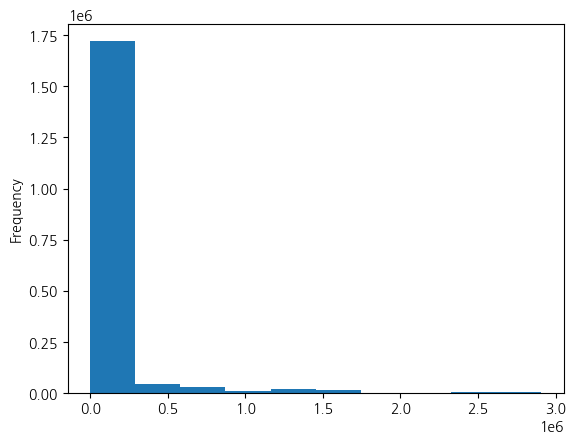

          is_fraud
city_pop          
7322      1.000000
7339      1.000000
7332      1.000000
7369      1.000000
7511      1.000000
...            ...
34882     0.000686
5875      0.000686
59744     0.000685
46563     0.000549
320420    0.000457

[873 rows x 1 columns]
============================== unix_time ==============================
count    1.852394e+06
mean     1.358674e+09
std      1.819508e+07
min      1.325376e+09
25%      1.343017e+09
50%      1.357089e+09
75%      1.374581e+09
max      1.388534e+09
Name: unix_time, dtype: float64
unix_time
1335110521    4
1370050667    4
1370177227    4
1381001869    4
1386957227    4
             ..
1325377215    1
1325377292    1
1325377326    1
1325377338    1
1325376044    1
Name: count, Length: 1819583, dtype: int64


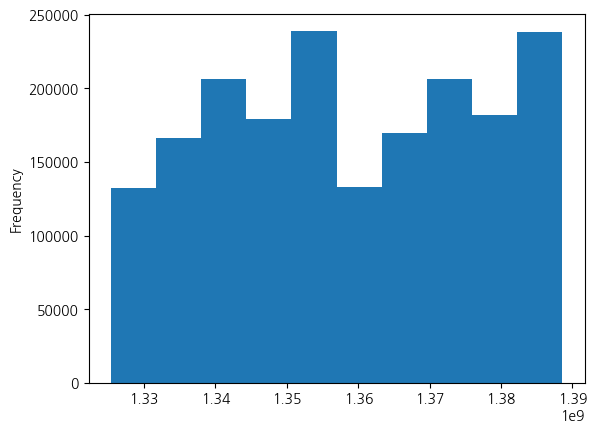

            is_fraud
unix_time           
1341538357  1.000000
1344862776  1.000000
1329090557  1.000000
1354665315  1.000000
1350857340  1.000000
...              ...
1374450545  0.333333
1344033754  0.333333
1380294793  0.333333
1371333830  0.333333
1381617099  0.333333

[9646 rows x 1 columns]
============================== merch_lat ==============================
count    1.852394e+06
mean     3.853898e+01
std      5.105604e+00
min      1.902742e+01
25%      3.474012e+01
50%      3.936890e+01
75%      4.195626e+01
max      6.751027e+01
Name: merch_lat, dtype: float64
merch_lat
39.545984    4
41.014694    4
40.016559    4
41.973278    4
39.516582    4
            ..
37.980931    1
43.987649    1
19.560013    1
38.742490    1
27.630593    1
Name: count, Length: 1754157, dtype: int64


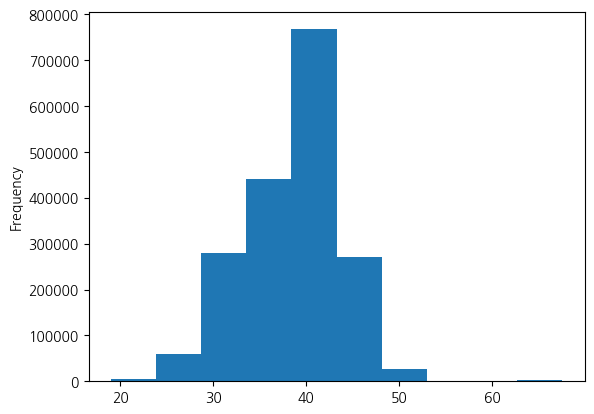

           is_fraud
merch_lat          
38.809769  1.000000
67.510267  1.000000
27.576053  1.000000
34.739887  1.000000
38.449115  1.000000
...             ...
40.552978  0.333333
40.358112  0.333333
38.447981  0.250000
41.308247  0.250000
41.204635  0.250000

[9649 rows x 1 columns]
============================== merch_long ==============================
count    1.852394e+06
mean    -9.022794e+01
std      1.375969e+01
min     -1.666716e+02
25%     -9.689944e+01
50%     -8.744069e+01
75%     -8.024511e+01
max     -6.695090e+01
Name: merch_long, dtype: float64
merch_long
-92.521318    4
-87.830842    4
-82.223196    4
-81.219189    4
-74.433003    4
             ..
-71.217297    1
-91.955115    1
-91.272903    1
-98.610225    1
-78.632459    1
Name: count, Length: 1809753, dtype: int64


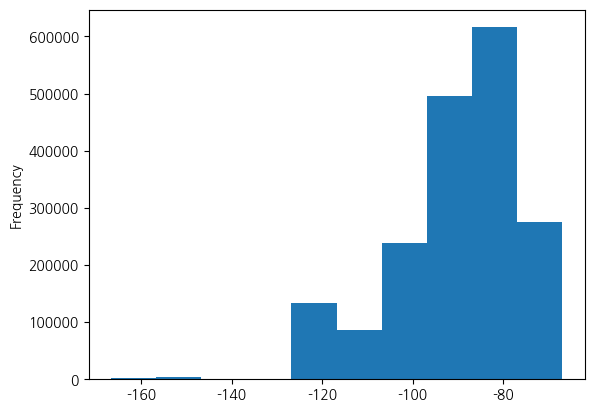

             is_fraud
merch_long           
-95.687871   1.000000
-89.176591   1.000000
-103.432490  1.000000
-87.651246   1.000000
-97.675129   1.000000
...               ...
-73.790264   0.333333
-77.753339   0.333333
-75.336649   0.333333
-84.905514   0.333333
-81.178745   0.333333

[9649 rows x 1 columns]


In [17]:
for col in num_cols.iloc[:,:-1]:
    print("="*30, col, "="*30)
    print(num_cols[col].describe())
    print(num_cols[col].value_counts())
    num_cols[col].plot(kind='hist')
    plt.show()
    
#     print(data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False))
    result = data[[col, 'is_fraud']].groupby(col).mean().sort_values(by='is_fraud', ascending=False)
    result = result[result['is_fraud'] > 0]
    print(result)